# 03 — Preference Dataset Construction

Build pairwise preference data from collected trajectories, simulating human preferences using a deterministic scoring function. Extract trajectory feature vectors for reward model training.

In [1]:
import sys
sys.path.insert(0, '../src')

import pickle
import random
import numpy as np
from pathlib import Path

DATA_DIR = Path('../data')
TRAJ_PATH = DATA_DIR / 'trajectories.pkl'
PAIRS_PATH = DATA_DIR / 'preference_pairs.pkl'
N_PAIRS = 1000
SEED = 42

assert TRAJ_PATH.exists(), f'Run notebook 02 first! Missing {TRAJ_PATH}'
random.seed(SEED)
np.random.seed(SEED)
print('Setup complete.')

Setup complete.


In [2]:
# Load trajectories
with open(TRAJ_PATH, 'rb') as f:
    trajectories = pickle.load(f)
print(f'Loaded {len(trajectories)} trajectories.')

Loaded 1000 trajectories.


In [3]:
def preference_score(traj: dict) -> float:
    """
    Simulated human preference score.
    Rewards: high return + landing bonus - fuel penalty (proxy for graceful landing).
    """
    total_return = traj['total_return']
    landing_bonus = 50.0 if traj['landed'] else 0.0
    # Fuel proxy: action 2 = main engine
    fuel_use = np.sum(traj['actions'] == 2)
    fuel_penalty = 0.2 * fuel_use
    return total_return + landing_bonus - fuel_penalty


N_ACTIONS = 4  # LunarLander-v3 discrete action space

def extract_features(traj: dict) -> np.ndarray:
    """
    Extract a fixed-size feature vector from a trajectory.
    Represents each trajectory as the mean of per-step (obs, one_hot_action)
    vectors — matching exactly what LearnedRewardWrapper feeds the model at
    inference time.

    Feature dim = obs_dim + n_actions = 8 + 4 = 12
    """
    states = traj['states']    # (T, 8)
    actions = traj['actions']  # (T,)

    # One-hot encode actions → (T, 4)
    action_onehot = np.zeros((len(actions), N_ACTIONS), dtype=np.float32)
    action_onehot[np.arange(len(actions)), actions] = 1.0

    # Per-step feature: [obs, one_hot_action] → (T, 12)
    step_feats = np.concatenate([states, action_onehot], axis=1)

    # Trajectory feature = mean over timesteps → (12,)
    return step_feats.mean(axis=0).astype(np.float32)

# Verify feature dim
sample_feat = extract_features(trajectories[0])
FEAT_DIM = len(sample_feat)
print(f'Feature dimension: {FEAT_DIM}')
print(f'Sample features: {sample_feat}')

Feature dimension: 12
Sample features: [ 3.26855183e-02  4.85925078e-01 -5.22919651e-03 -1.97926551e-01
  1.30690914e-02  2.99489620e-04  2.96529979e-01  2.96529979e-01
  4.03785497e-01  1.10410094e-01  3.72239739e-01  1.13564670e-01]


In [4]:
# Pre-compute scores and features
scores = [preference_score(t) for t in trajectories]
features = [extract_features(t) for t in trajectories]

print(f'Score stats: mean={np.mean(scores):.1f}, std={np.std(scores):.1f}, '
      f'min={np.min(scores):.1f}, max={np.max(scores):.1f}')

Score stats: mean=277.6, std=70.6, min=-39.3, max=349.9


In [5]:
# Build preference pairs
indices = list(range(len(trajectories)))
pairs = []

for _ in range(N_PAIRS):
    i, j = random.sample(indices, 2)
    label = 1 if scores[i] > scores[j] else 0  # 1 if A preferred
    pairs.append({
        'feat_A': features[i],
        'feat_B': features[j],
        'label': label,
        'score_A': scores[i],
        'score_B': scores[j],
    })

label_dist = np.mean([p['label'] for p in pairs])
print(f'Built {len(pairs)} preference pairs.')
print(f'Label distribution: A preferred {label_dist:.2%}, B preferred {1-label_dist:.2%}')

Built 1000 preference pairs.
Label distribution: A preferred 51.40%, B preferred 48.60%


In [6]:
# Save preference pairs
with open(PAIRS_PATH, 'wb') as f:
    pickle.dump(pairs, f)

# Also save feature dim for reward model
meta = {'feat_dim': FEAT_DIM, 'n_pairs': len(pairs)}
with open(DATA_DIR / 'dataset_meta.pkl', 'wb') as f:
    pickle.dump(meta, f)

print(f'Saved {len(pairs)} pairs to {PAIRS_PATH}')
print(f'Feature dim={FEAT_DIM} saved to dataset_meta.pkl')

Saved 1000 pairs to ../data/preference_pairs.pkl
Feature dim=12 saved to dataset_meta.pkl


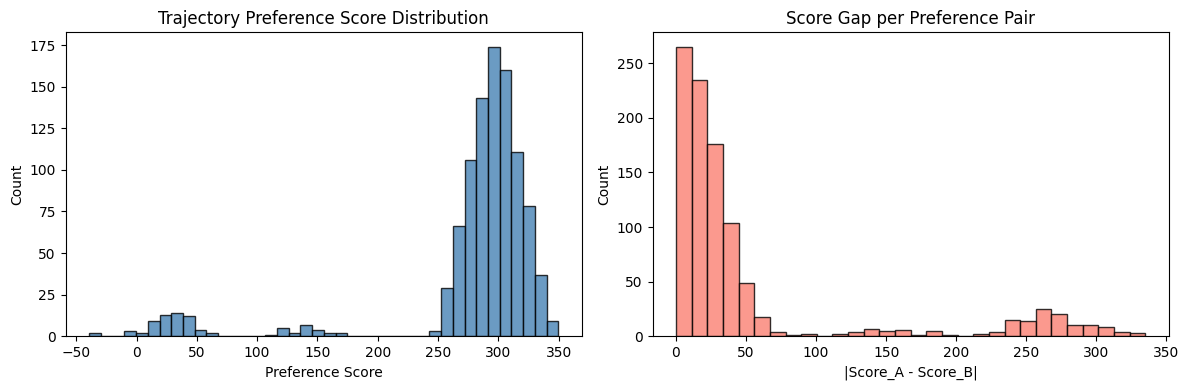

In [7]:
# Visualise preference score distribution
import matplotlib.pyplot as plt

score_gaps = [abs(p['score_A'] - p['score_B']) for p in pairs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(scores, bins=40, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Preference Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Trajectory Preference Score Distribution')

axes[1].hist(score_gaps, bins=30, color='salmon', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('|Score_A - Score_B|')
axes[1].set_ylabel('Count')
axes[1].set_title('Score Gap per Preference Pair')

plt.tight_layout()
plt.savefig('../checkpoints/preference_data_stats.png', dpi=100)
plt.show()